# Exploratory Data Analysis

This notebook performs the initial exploration of the Banking77 dataset. The goal is to understand the dataset's structure, inspect data quality, analyze class distribution, and identify patterns that may influence the preprocessing and modeling stages.

The insights obtained from this analysis will guide the design of the text preprocessing pipeline and the subsequent machine learning workflow.

In [21]:
import pandas as pd
df = pd.read_csv("../data/raw.csv")

In [22]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 100)

df.sample(5)

,text,label,label_text
2332,my atm transaction was wrong,75,wrong_amount_of_cash_received
9304,"You can do that in just a few seconds. Go to account, hit activate, and follow the directions from there.",0,activate_my_card
4595,\nWhere can I withdraw money from?,3,atm_support
7271,Why did I get charged a fee for transferring money?,64,transfer_fee_charged
6475,Why is there a payment showing twice?,63,transaction_charged_twice


## Dataset Overview

Before performing exploratory analysis, the dataset is inspected to verify its structure, data types, uniqueness, and the presence of duplicate records. This initial inspection helps assess the overall quality of the dataset and identify any issues that may require preprocessing.

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        10003 non-null  str  
 1   label       10003 non-null  int64
 2   label_text  10003 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1022.0 KB


In [24]:
print(f"Duplicated rows: {df.duplicated().sum()}")

Duplicated rows: 0


In [25]:
df.nunique()

text          10003
label            77
label_text       77
dtype: int64

**Observation**

- The dataset contains the expected columns with appropriate data types.
- No duplicated rows were found.
- Each feature has the expected number of unique values, confirming the dataset's integrity before further analysis.

## Class Distribution Variability

To quantify the degree of class imbalance, the **Coefficient of Variation (CV)** was calculated using the frequency of each label. Unlike simply comparing the largest and smallest classes, CV provides a normalized measure of how much class frequencies vary relative to their mean.

A higher CV indicates greater variability in class distribution, while a lower CV suggests a more balanced dataset. This metric helps assess the severity of class imbalance and supports the choice of evaluation metrics during model development.

In [26]:
label_counts = df["label_text"].value_counts()
label_counts.describe()

count     77.000000
mean     129.909091
std       32.942207
min       35.000000
25%      112.000000
50%      127.000000
75%      159.000000
max      187.000000
Name: count, dtype: float64

In [27]:
cv = label_counts.std()/label_counts.mean()
print(f"Coefficient of Variation = {cv}")

Coefficient of Variation = 0.2535789194276306


**Observation**

The computed coefficient of variation indicates a **moderate level of class imbalance**. Therefore, macro-averaged evaluation metrics (e.g., Macro Precision, Macro Recall, and Macro F1-score) are more appropriate than relying solely on accuracy.

## Text Length Analysis

A new feature, **`word_count`**, was created to analyze the distribution of text lengths across the dataset.

The distribution was visualized using a histogram to identify potential outliers and understand the overall shape of the data. The histogram revealed a **right-skewed distribution**, indicating that most customer queries are relatively short while a small number of samples contain substantially more words.

In [28]:
def words_counter(text):
    return len(text.split())

df["word_count"] = df["text"].apply(words_counter)

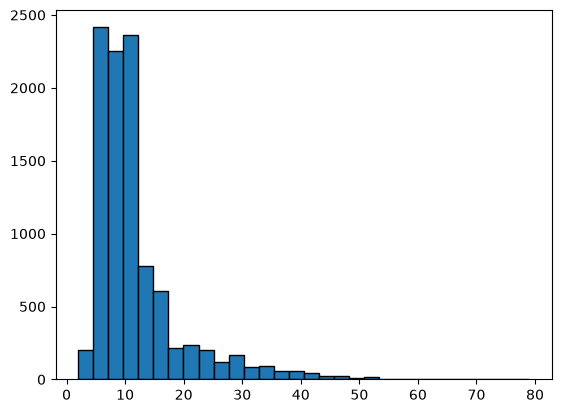

In [29]:
import matplotlib.pyplot as plt

plt.hist(df["word_count"], bins=30, edgecolor="black")
plt.show()

In [30]:
df["word_count"].describe()

count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: word_count, dtype: float64

To further summarize the distribution, descriptive statistics were examined, including the minimum, maximum, mean, median, and quartiles. These statistics provide a clearer understanding of text length variability and help identify unusually long or short samples for further inspection.

## Outlier Detection in Text Length

To further investigate the distribution of text lengths, the **Interquartile Range (IQR)** method was applied using the first and third quartiles.

This analysis was performed to:
- Identify unusually short or long text samples.
- Quantify the number of statistical outliers.
- Determine whether these observations represent data quality issues or naturally occurring long customer queries.

Since text datasets often contain legitimate long requests, detected outliers were inspected before considering any preprocessing decisions.

In [31]:
Q1 = df["word_count"].quantile(0.25)
Q3 = df["word_count"].quantile(0.75)

IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

outliers = df[df["word_count"] > upper].sort_values(by="word_count", ascending=False)

In [32]:
outliers["word_count"].describe()

count    930.000000
mean      32.319355
std        8.744683
min       23.000000
25%       26.000000
50%       30.000000
75%       36.000000
max       79.000000
Name: word_count, dtype: float64

## Inspecting Long Text Samples

The longest text samples were manually reviewed to determine whether the detected statistical outliers were genuine data quality issues or valid customer messages.

In [33]:
outliers[["text", "label_text"]].head()

,text,label_text
3917,"Hearing back from us regarding your important verification results may take 10 minutes to one hour time. If verification results do fail, double-check to make sure all of your images are clear -- make sure your photos have no glare or blurring. Note: These photos need to be readable as well. You also need to be 18 years of age or older. You must be a resident of Switzerland or the European Economic Area to open a new account.",unable_to_verify_identity
7310,"Hi! I'm a university student studying abroad and I noticed that when I was trying to cross-reference my budget for this month that there were extra fees I was not expecting. Why is that? I've had this account for years and I haven't had any trouble so far, it might not even be on your all's end since I'm still new to international travel and finance, but I wanted to double check in case a mistake was made!",transfer_fee_charged
3934,"Hearing about your verification results from us may take anywhere from 10 minutes to approximately one hour. If this verification has in fact, failed, double-check to make sure that your images are clear. Also make sure that your document photos have no blur or glare. They need to be readable. You must also be 18 years of age or older and be a resident of Switzerland or the European Economic Area to open an account.",unable_to_verify_identity
3910,It can take between 10 minutes to an hour before you hear back from us about the verification result. Please try again if your verification fails. Make sure you double check that images are clear and all document photos are readable without blur or glare. You have to be 18 or older and live in the European Economic area or live in Switzerland to be able to open an account.,unable_to_verify_identity
3905,"You will hear back from us about your verification results in 10 minutes to a one hour timeframe. If these verification results do fail, please double-check to make sure your images are clear and have no glare or blur; your photos need to be fully readable. You need to be 18 years of age or older and a resident of Switzerland or the European Economic Area to create an account.",unable_to_verify_identity


Although a few samples were considerably longer than the majority of the dataset, manual inspection showed that they were legitimate records rather than corrupted or duplicated data. Some of these messages appeared to contain automated verification instructions, which naturally resulted in longer text lengths.

Therefore, no samples were removed based solely on their length.

## Outlier Distribution Across Labels

After identifying text-length outliers using the IQR method, their distribution across the intent labels was examined.

In [34]:
outliers["label_text"].value_counts().head(10)

label_text
transfer_not_received_by_recipient         51
transfer_fee_charged                       41
failed_transfer                            38
Refund_not_showing_up                      38
pending_transfer                           37
direct_debit_payment_not_recognised        37
balance_not_updated_after_bank_transfer    37
transaction_charged_twice                  36
request_refund                             34
cancel_transfer                            34
Name: count, dtype: int64

The analysis showed that outliers were not randomly distributed across all intents. Instead, certain labels contained a larger number of long text samples. For example, the `transfer_not_received_by_recipient` intent included **51** outlier messages.

This observation suggests that some customer intents naturally involve more detailed descriptions, rather than indicating data quality issues. Therefore, the detected outliers were retained for subsequent analysis and modeling.

## Character Length Analysis by Intent

A **`char_count`** feature was created to measure the length of each text sample in characters.

The median character count was then computed for each intent to compare the typical message length across different labels. The **median** was preferred over the mean because text length distributions are right-skewed and may contain unusually long messages.

This analysis helps identify whether certain intents naturally involve longer or shorter customer requests.

In [35]:
def chars_counter(text):
    return len(text)

df["char_count"] = df["text"].apply(chars_counter)

In [36]:
stats = (
    df.groupby(["label", "label_text"])["char_count"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"char_count": "median_char_count"})
)
stats.head()

,label,label_text,median_char_count
0,17,card_payment_wrong_exchange_rate,66.0
1,76,wrong_exchange_rate_for_cash_withdrawal,65.0
2,6,balance_not_updated_after_cheque_or_cash_deposit,65.0
3,22,compromised_card,61.5
4,20,cash_withdrawal_not_recognised,61.0


## Utterance Type Extraction

A new feature named **`utterance_type`** was created to categorize each customer message as either a **question** or a **request**.

Messages containing a question mark (`?`) were classified as **questions**, while all remaining messages were classified as **requests**.

This feature enables an analysis of how different intents are expressed and whether certain intents are more likely to appear as questions or requests.

In [37]:
import re

def utterance_type(text):
    return "Question" if bool(re.search(r"\S+\?", text)) is True else "Request"

df["utterance_type"] = df["text"].apply(utterance_type)


## Overall Utterance Type Distribution

The distribution of utterance types was examined to understand how customers typically express their requests.

In [38]:
result = df.groupby(["label", "label_text", "utterance_type"]).size().unstack(fill_value=0).reset_index()

result.columns.name = None
result = result.rename(columns={"Question": "num_questions", "Request": "num_requests"})
result.head()

,label,label_text,num_questions,num_requests
0,0,activate_my_card,94,65
1,1,age_limit,98,12
2,2,apple_pay_or_google_pay,99,27
3,3,atm_support,76,11
4,4,automatic_top_up,113,14


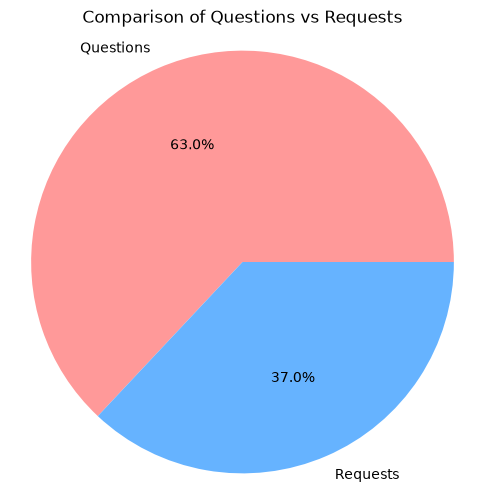

In [39]:
import matplotlib.pyplot as plt

total_questions = result["num_questions"].sum()
total_requests = result["num_requests"].sum()

labels = ["Questions", "Requests"]
sizes = [total_questions, total_requests]
colors = ["#ff9999", "#66b3ff"]

plt.figure(figsize=(6, 6))
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%',
    colors=colors
)

plt.title("Comparison of Questions vs Requests")
plt.axis("equal") 

plt.show()

Each message was categorized as either a **question** or a **request**, and the overall proportion of each category was visualized. This provides a high-level overview of the communication style within the dataset before analyzing individual intents.

## Question Ratio by Intent

To compare communication patterns across intents fairly, the percentage of **questions** and **requests** was calculated for each label instead of relying on raw counts.

In [40]:
row_totals = result["num_questions"] + result["num_requests"]

result["questions_%"] = ((result["num_questions"] / row_totals) * 100).round(2)
result["requests_%"] = ((result["num_requests"] / row_totals) * 100).round(2)

In [44]:
question_summary = (
    result[["label_text", "questions_%", "requests_%"]]
    .sort_values("questions_%", ascending=False)
)

top_5_questions = question_summary.head()
bottom_5_questions = question_summary.tail()

In [45]:
from IPython.display import display

display(top_5_questions)
display(bottom_5_questions)

,label_text,questions_%,requests_%
56,top_up_by_bank_transfer_charge,93.69,6.31
10,card_acceptance,93.22,6.78
31,exchange_charge,92.56,7.44
67,transfer_timing,92.19,7.81
50,receiving_money,91.58,8.42


,label_text,questions_%,requests_%
16,card_payment_not_recognised,27.98,72.02
17,card_payment_wrong_exchange_rate,27.54,72.46
20,cash_withdrawal_not_recognised,23.75,76.25
55,terminate_account,22.22,77.78
76,wrong_exchange_rate_for_cash_withdrawal,22.09,77.91


Using percentages avoids bias caused by differences in class sizes, allowing a fair comparison across intents.

The analysis revealed substantial variation in how intents are expressed. The highest-ranked intent `top_up_by_bank_transfer_charge` consisted of **93.6% questions**, whereas the lowest `wrong_exchange_rate_for_cash_withdrawal` contained only **22.1% questions**, indicating that some intents are naturally phrased as questions while others are predominantly written as requests.

## Save Processed Dataset

The dataset, including the newly engineered features created during the exploratory analysis, is saved in **Parquet** format for use in the preprocessing stage. Using Parquet provides efficient storage and faster loading while preserving data types.

In [47]:
df.to_parquet("../data/eda.parquet", index=False)